#Growth Model

In [1]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.dynamic_factor import DynamicFactor
from sklearn.metrics import mean_squared_error
import warnings
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

warnings.simplefilter("ignore")

In [5]:
SRC   = "Growth_monthly_combined.xlsx"
SHEET = "Smoothed_Monthly"

np.random.seed(0)

def load_panel():
    raw = pd.read_excel(SRC, sheet_name=SHEET, parse_dates=["date"])
    raw = raw.set_index("date")

    panel = pd.DataFrame({
        "ism": raw["ISM_NEWORDERS"],
        "t10y2y_avg": raw["T10Y2Y_AVG"],
        "t10y2y_eom": raw["T10Y2Y_EOM"],
        "icsa_avg": raw["ICSA_AVG"],
        "icsa_eom": raw["ICSA_EOM"],
        "spx_avg": raw["SPX_AVG"],
        "spx_eom": raw["SPX_EOM"],
        "nfci_avg": raw["NFCI_AVG"],
        "nfci_eom": raw["NFCI_EOM"],
        "permit": raw["PERMIT"],
    })

    panel.index.name = "date"
    return panel.sort_index()


def transform(panel, start="2003-01-31", end="2026-08-31"):
    panel = panel[(panel.index >= start) & (panel.index <= end)]
    tf = panel.dropna().copy()
    return tf


def fit_dfm(z_train, start_params=None):
    z_train = z_train.copy()
    z_train.index.freq = "ME"

    mod = DynamicFactor(
        z_train,
        k_factors=1,
        factor_order=2,
        error_order=1,
        error_cov_type="diagonal"
    )

    if start_params is not None:
        res = mod.fit(start_params=start_params, method="lbfgs", maxiter=150, disp=False)
    else:
        res = mod.fit(method="lbfgs", maxiter=300, disp=False)

    return mod, res


def rolling_window(df, target_col="ism", train_window_size=102, rolling=False):
    n_obs = len(df)
    test_dates    = []
    actual_vals   = []
    forecast_vals = []
    last_res = None

    for t in range(train_window_size, n_obs):
        start_idx = (t - train_window_size) if rolling else 0
        train_df  = df.iloc[start_idx:t]
        test_obs  = df.iloc[t]
        target_date = df.index[t]

        train_means = train_df.mean()
        train_stds  = train_df.std()
        z_train     = (train_df - train_means) / train_stds

        start_p = last_res.params if last_res is not None else None
        try:
            mod, last_res = fit_dfm(z_train, start_params=start_p)
        except Exception:
            mod, last_res = fit_dfm(z_train, start_params=None)

        pred_z = last_res.get_prediction(
            start=len(z_train), end=len(z_train)
        ).predicted_mean

        z_target_pred = pred_z[target_col].iloc[0]
        target_pred_unscaled = z_target_pred * train_stds[target_col] + train_means[target_col]

        test_dates.append(target_date)
        actual_vals.append(test_obs[target_col])
        forecast_vals.append(target_pred_unscaled)

    oos_df = pd.DataFrame(
        {"actual": actual_vals, "forecast": forecast_vals},
        index=pd.to_datetime(test_dates)
    )

    test_rmse = np.sqrt(np.mean((oos_df["actual"] - oos_df["forecast"]) ** 2))
    test_corr = oos_df[["actual", "forecast"]].corr().iloc[0, 1]

    return oos_df, test_rmse, test_corr


if __name__ == "__main__":
    panel = load_panel()
    tf = transform(panel)

    oos_results, test_rmse, test_corr = rolling_window(
        tf, target_col="ism", train_window_size=102, rolling=False
    )

    actual_std = oos_results["actual"].std()
    rmse_ratio = test_rmse / actual_std

    print("Out-of-Sample Results:")
    print(f"  Out-of-Sample Test RMSE:        {test_rmse:.3f}")

Out-of-Sample Results:
  Out-of-Sample Test RMSE:        3.565


In [17]:
def generate_ism_forecast(df, steps=9, target_col="ism", alpha=0.05):
    means = df.mean()
    stds = df.std()
    z_df = (df - means) / stds

    # Fits the Dynamic Factor Model defined in your notebook
    _, res = fit_dfm(z_df)

    forecast_res = res.get_forecast(steps=steps)
    z_pred_mean = forecast_res.predicted_mean
    z_conf_int = forecast_res.conf_int(alpha=alpha)

    # Rescale mean and confidence bands to original units
    target_mean = means[target_col]
    target_std = stds[target_col]

    fc_df = pd.DataFrame(
        {
            "forecast": z_pred_mean[target_col] * target_std + target_mean,
            "lower_ci": z_conf_int[f"lower {target_col}"] * target_std
            + target_mean,
            "upper_ci": z_conf_int[f"upper {target_col}"] * target_std
            + target_mean,
        },
        index=z_pred_mean.index,
    )

    return fc_df


def plot_ism_forecast(df, fc_df, target_col="ism", history_months=24, show_expansion_line=True):
    recent_history = df[target_col].iloc[-history_months:]

    fig, ax = plt.subplots(figsize=(11, 5.5), dpi=120)

    # Historical series
    ax.plot(
        recent_history.index,
        recent_history.values,
        label="Historical ISM New Orders",
        color="#1f77b4",
        linewidth=2.2,
    )

    # Continuous connection: stitch the last historical point to the forecast path
    plot_dates = [recent_history.index[-1]] + list(fc_df.index)
    plot_forecast = [recent_history.values[-1]] + list(fc_df["forecast"])
    plot_lower = [recent_history.values[-1]] + list(fc_df["lower_ci"])
    plot_upper = [recent_history.values[-1]] + list(fc_df["upper_ci"])

    # Forecast line and uncertainty band
    ax.plot(
        plot_dates,
        plot_forecast,
        label=f"{len(fc_df)}-Month Forecast",
        color="#d62728",
        linewidth=2.2,
        linestyle="--",
        marker="o",
    )
    ax.fill_between(
        plot_dates,
        plot_lower,
        plot_upper,
        color="#d62728",
        alpha=0.15,
        label="95% Confidence Interval",
    )

    # Value callouts on forecast points
    for dt, val in zip(fc_df.index, fc_df["forecast"]):
        ax.annotate(
            f"{val:.1f}",
            xy=(dt, val),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            fontweight="bold",
            color="#a31d1d",
        )

    if show_expansion_line:
        ax.axhline(
            50,
            color="gray",
            linestyle=":",
            linewidth=1.2,
            alpha=0.7,
            label="Neutral (50)",
        )

    ax.set_title(
        "ISM: 9-Month Dynamic Factor Forecast",
        fontsize=13,
        fontweight="bold",
        pad=14,
    )
    ax.set_xlabel("Date", fontsize=11)
    ax.set_ylabel("ISM New Orders Index", fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.grid(True, linestyle=":", alpha=0.55)
    ax.legend(loc="upper left", frameon=True)

    plt.tight_layout()
    plt.show()

Projected Values: 


,forecast,lower_ci,upper_ci
2026-09,53.70,28.27,79.14
2026-10,53.70,17.44,89.96
2026-11,53.70,9.40,98.01
2026-12,53.71,2.80,104.61
2027-01,53.71,-2.86,110.28
2027-02,53.71,-7.85,115.27
2027-03,53.71,-12.33,119.75
2027-04,53.71,-16.40,123.82
2027-05,53.72,-20.12,127.55


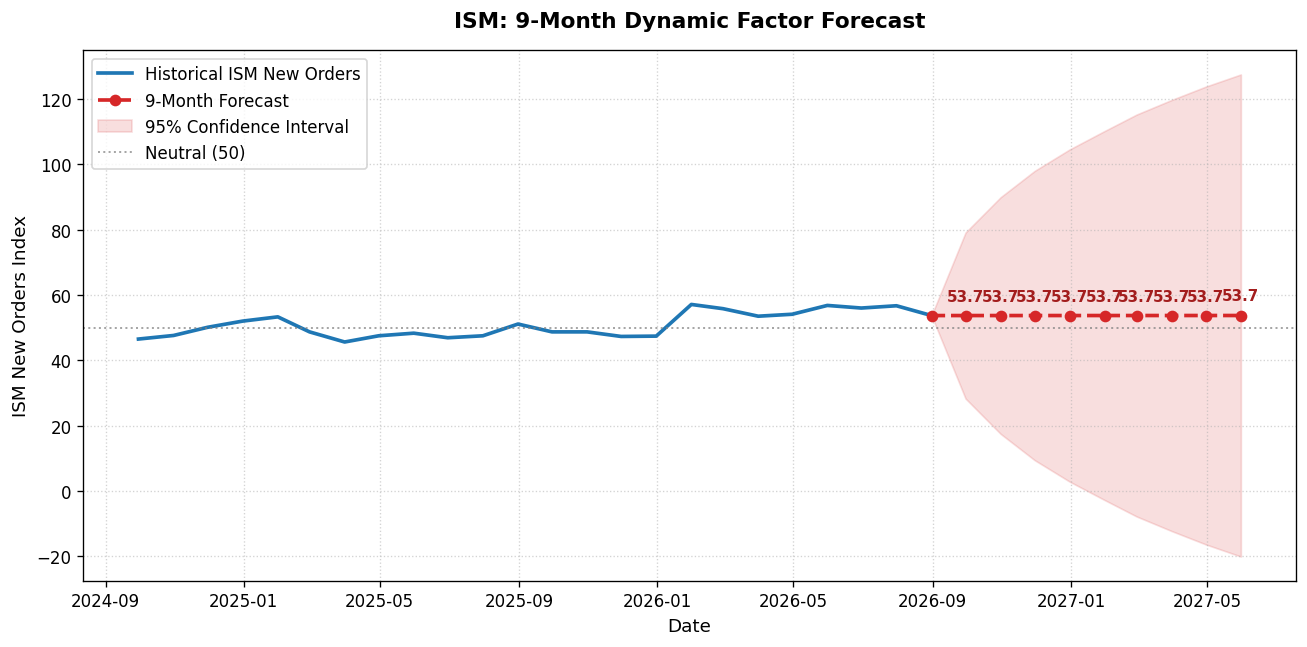

In [18]:
forecast_9m = generate_ism_forecast(tf, steps=9, target_col="ism", alpha=0.05)

# Display tabular values
print("Projected Values: ")
display_df = forecast_9m.copy()
display_df.index = display_df.index.strftime("%Y-%m")
display(display_df.round(2))

# Render chart (showing 24 months of prior history)
plot_ism_forecast(tf, forecast_9m, target_col="ism", history_months=24)